## Sub-task 1: Unsupervised Learning
This notebook presents the implementation of loading a dataset with assigned column names and applying k-means clustering to partition it into three clusters. The resulting clusters are visualized using scatter plots. 

To evaluate the clustering quality, a colleague’s claim regarding the consistency and optimality of k-means is critically analyzed using Elbow Method by plotting the Within-Cluster Sum of Squares (WSS) to identify the optimal number of clusters.

In [14]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [10]:
# Load the dataset
df = pd.read_csv('cluster.csv', header=None, names=['col_1', 'col_2'])
print(len(df))

500


In [12]:
df.head(10)

,col_1,col_2
0,2.7759,-1.47160
1,6.1090,0.99685
2,3.2623,-1.30980
3,2.2895,-0.43370
4,2.2404,-4.09190
5,3.0494,-0.31212
6,6.7528,0.53207
7,2.2169,-4.21420
8,3.0078,-0.72753
9,6.8539,-0.85916


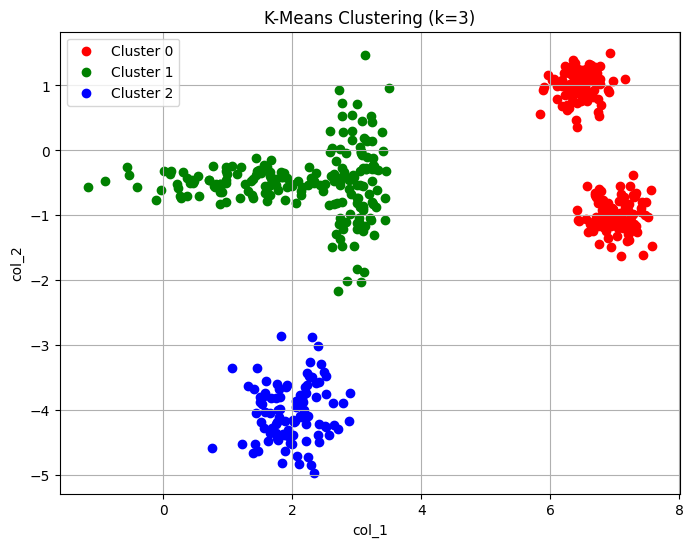

In [ ]:
# Apply KMeans to partition into 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df)

# Plot the clusters
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for i in range(3):
    cluster_data = df[df['cluster'] == i]
    plt.scatter(cluster_data['col_1'], cluster_data['col_2'], color=colors[i], label=f'Cluster {i}')

plt.title('K-Means Clustering (k=3)')
plt.xlabel('col_1')
plt.ylabel('col_2')
plt.legend()
plt.grid(True)
plt.show()


#### Systemetaiclly analyse the colleague claims

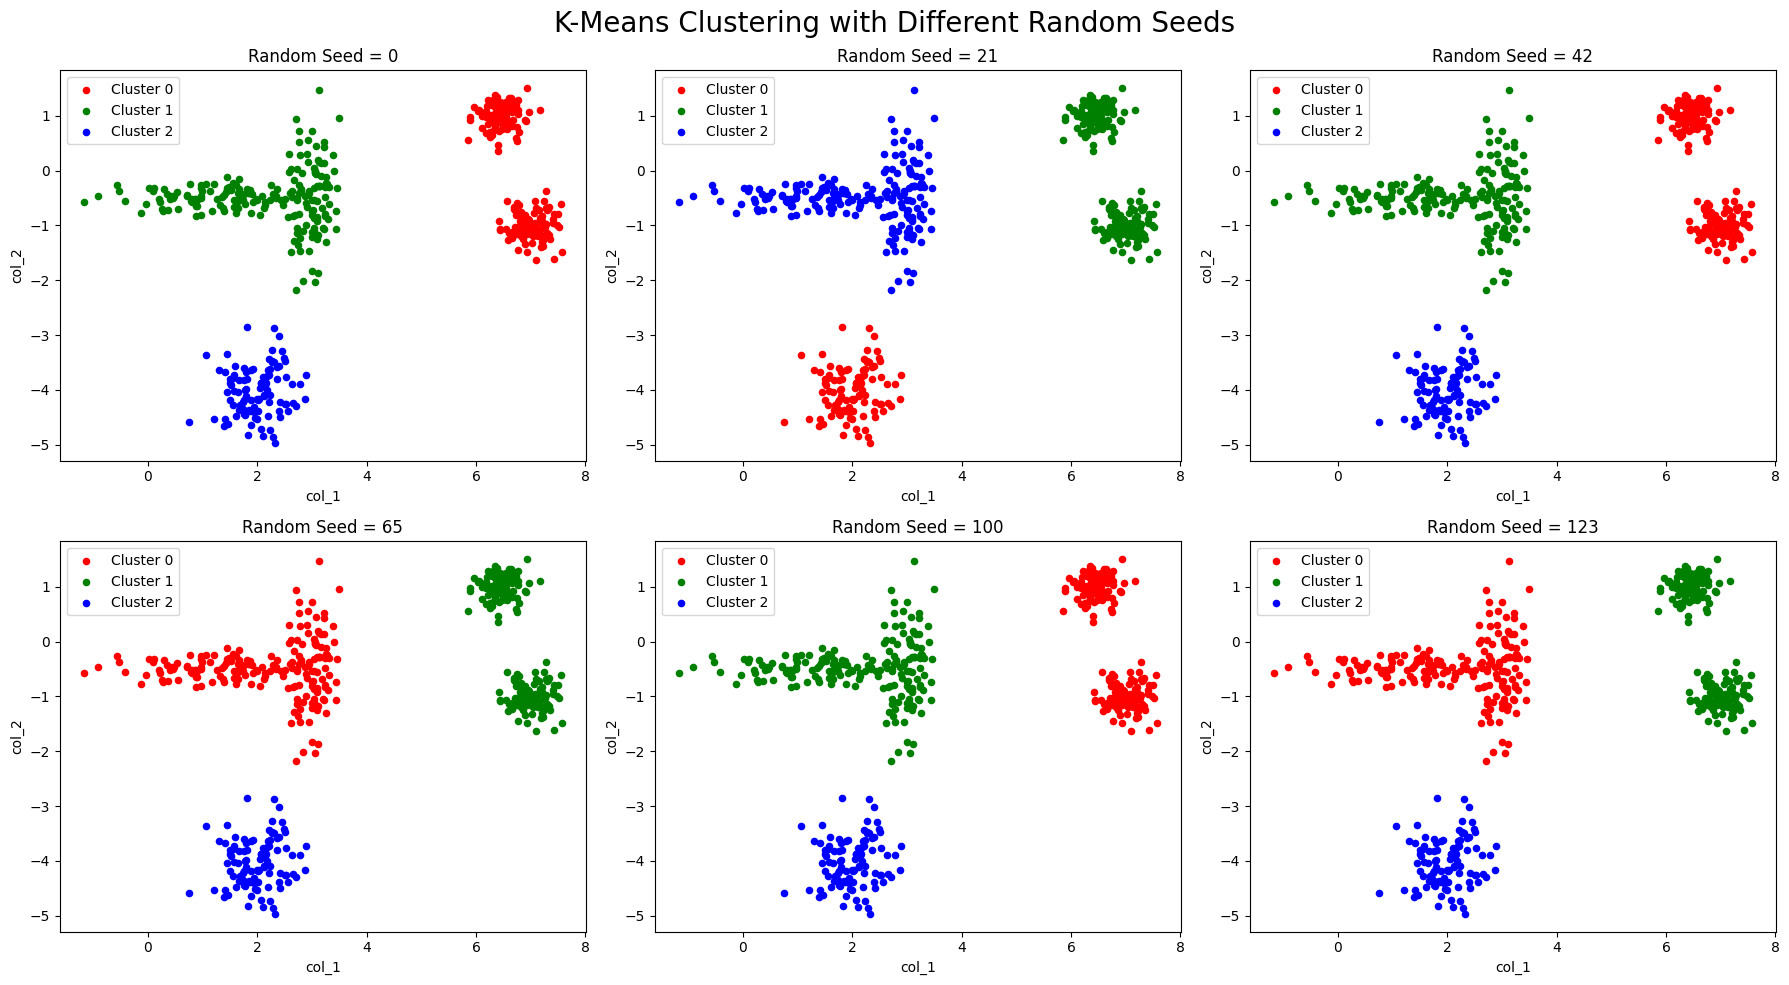

In [20]:
# Apply KMeans to partition into 3 clusters with different random seed value

# Define random seeds to test
random_seeds = [0, 21, 42, 65, 100, 123]

# Plotting setup
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Colors for clusters
colors = ['red', 'green', 'blue']

# Loop through seeds and plot
for idx, seed in enumerate(random_seeds):
    if idx >= len(axes):  # Just in case
        break
    kmeans = KMeans(n_clusters=3, random_state=seed)
    df['cluster'] = kmeans.fit_predict(df)

    ax = axes[idx]
    for i in range(3):
        cluster_data = df[df['cluster'] == i]
        ax.scatter(cluster_data['col_1'], cluster_data['col_2'], color=colors[i], label=f'Cluster {i}', s=20)
    ax.set_title(f'Random Seed = {seed}')
    ax.set_xlabel('col_1')
    ax.set_ylabel('col_2')
    ax.legend()

# Hide any extra subplots
for i in range(len(random_seeds), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('K-Means Clustering with Different Random Seeds', fontsize=20)
plt.tight_layout()
plt.show()


Insight gained:

Since data is cleanly separable into clusters, K-Means often converges fast because it finds a local minimum efficiently, claim 1  is correct.

Based on the obtained plots, Claim 2 that each run of the algorithm with different random seeds shows very similar clusters is correct.


#### Apply Elbow Method to find the optimal number of clusters by plotting the WSS (Within-Cluster Sum of Squares) against the number of clusters.

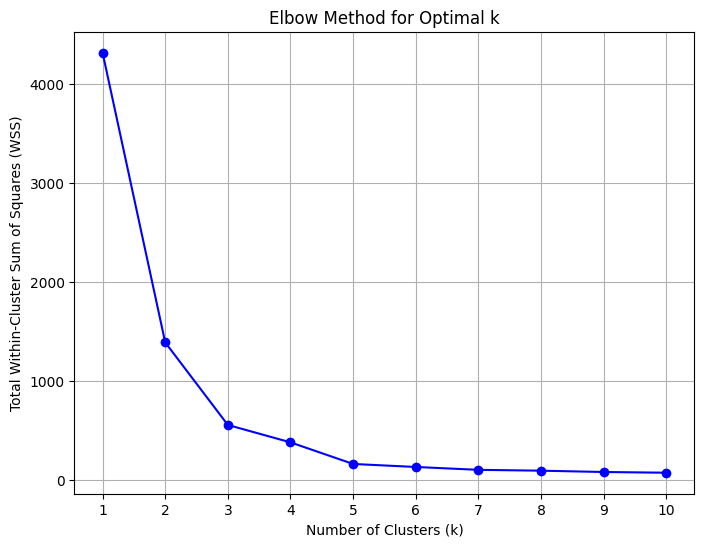

In [22]:
# Prepare data (you can choose relevant columns for clustering)
X = df[['col_1', 'col_2']]

# Store WSS values
wss = []

# Try different values of k (1 to 10)
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wss.append(kmeans.inertia_)  # inertia_ is the total WSS

# Plot the elbow graph
plt.figure(figsize=(8, 6))
plt.plot(k_values, wss, 'bo-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Total Within-Cluster Sum of Squares (WSS)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Insight gained:

Since the elbow is at k=3 (i.e., the Sum of squared distances falls suddenly), indicating the optimal k for this dataset is 3. the claim 3 is correct.